## Part 1 Answering Questions

### 1. What relevant key metrics are provided to evaluate the CTA combinations? And which CTA Copy and CTA Placement did best or worst based on the key metrics?

The most relevant metrics in this case are:
- **CTR (click-through rate)**, because the predictive target is `clickedCTA`
- **Form submission rate**, because it reflects movement deeper into the funnel
- **Scheduled appointment rate**, because appointments are closer to the business outcome
- **Revenue per impression**, because the broader business goal is to increase revenue, not just clicks

At the overall level:
- **CTR** = **17.26%**
- **Form submission rate** = **14.79%**
- **Scheduled appointment rate** = **5.52%**
- **Revenue per impression** = **$12.03**

At the CTA copy level:
- **Best CTR copy**: **Get Pre-Approved for a Mortgage in 5 Minutes** at **18.31%**
- **Best revenue-per-impression copy**: **First Time? We've Made it Easy to Find the Best Mortgage Rate** at **$12.42**
- **Worst copy** on both CTR and revenue: **Access Your Personalized Mortgage Rates Now** at **16.09% CTR** and **$11.63 revenue per impression**

At the CTA placement level:
- **Best placement for CTR and revenue**: **Top** at **19.89% CTR** and **$12.36 revenue per impression**
- **Worst placement for CTR**: **Bottom** at **14.74%**
- **Worst placement for revenue per impression**: **Middle** at **$11.75**

At the full CTA combination level:
- **Highest CTR combination**: **Get Pre-Approved for a Mortgage in 5 Minutes + Top** at **21.18%**
- **Highest revenue-per-impression combination**: **First Time? We've Made it Easy to Find the Best Mortgage Rate + Bottom** at **$12.91**
- **Weakest combination on both CTR and revenue**: **Access Your Personalized Mortgage Rates Now + Bottom** at **13.48% CTR** and **$11.33 revenue per impression**

A key business insight is that the **CTR winner and the revenue winner are different**. This means that optimizing only for clicks may not maximize downstream business value.

### 2. Which groups of people tend to be more correlated or less correlated with our key metrics?

Several user groups show meaningful differences in click and monetization behavior.

Groups more positively correlated with the key metrics:
- **Direct** and **Email** traffic sources
- **Desktop** users
- **Firefox** and **Edge** users
- **Apartment** users
- **Repeat visitors**, especially users with **2 visits** and **3-5 visits**

Groups less positively correlated with the key metrics:
- **Social** traffic, which is the weakest segment by a wide margin
- **Mobile** users relative to desktop
- **Safari** users relative to the other browsers
- **House** users relative to apartment users
- **First-visit users** relative to repeat visitors

An additional nuance is that the **highest income band does not have the highest CTR, but it does have the highest revenue per impression**. This suggests that some groups may click less often while still delivering more downstream value once they convert.

These patterns support the idea that a **personalized CTA strategy** is likely to outperform a single universal CTA.

### 3. What ways can you manipulate the columns/dataset to create features that increase predictive power towards our key metric?

To improve predictive power while staying faithful to the real decision setting, I would focus on feature engineering that uses only variables available at the time the CTA is shown.

The main feature engineering strategies are:
- **Calendar features** from `date`, such as **day of week** and **weekend indicator**
- **Missingness features**, such as an **income missing flag** for `estimatedAnnualIncome`
- **Binned features**, such as **income bands** and **visit frequency bands**
- **Interaction features** to capture conditional CTA performance, including:
  - `ctaCopy x ctaPlacement`
  - `deviceType x ctaPlacement`
  - `sessionReferrer x ctaCopy`
- **Lightweight text features** from `editorialSnippet`, such as **character count** and **word count**
- **Page-context signals** from `pageURL`, since page topic appears to matter

These features help the model capture both broad user intent and context-specific CTA effectiveness.

### 4. Besides Log Loss, what other metrics will you use to evaluate the model's performance, and why?

Although **log loss** is the primary metric because it is the official scoring metric and directly evaluates probability quality, I would also use the following metrics:

- **ROC-AUC**: measures how well the model ranks positive cases above negative cases
- **PR-AUC (average precision)**: more informative than ROC-AUC when the positive class is less common and we care about identifying likely clickers
- **Brier score**: evaluates the accuracy of predicted probabilities and is useful for calibration
- **Calibration curve**: shows whether predicted probabilities align with observed click rates
- **Lift or decile analysis**: helps interpret business usefulness by showing whether top-scored users are materially more likely to click than average

These metrics provide a more complete view of model quality than log loss alone, especially since this problem requires both good ranking and good probability estimation.

### Optional 1. What additional predictive model would you build to inform which CTA combinations would maximize the revenue in addition to predict ClickedCTA, and why?

In addition to the click model, I would build an **expected revenue model**. One practical approach would be to estimate:

- `Pr(scheduledAppointment = 1 | user, context, CTA)`
- expected revenue conditional on appointment, or directly:
- `E(revenue | user, context, CTA)`

This would be useful because the business objective is not only to maximize clicks, but also to maximize **appointments and revenue**. A CTA that generates more clicks is not necessarily the CTA that generates the most revenue. A revenue-oriented model would help the business choose the CTA combination with the highest expected value rather than the highest click rate alone.

### Optional 2. If we called one of these CTA combinations our champion (serve it 100% of the time), how much incrementally is that worth to us vs. the average of the rest of the split test?

If we define the champion as the **highest revenue-per-impression** CTA combination, the champion is:

- **First Time? We've Made it Easy to Find the Best Mortgage Rate + Bottom**
- **Revenue per impression = $12.91**

The average revenue per impression of the **other eight combinations** is approximately **$11.92**.

That implies an incremental value of about:

- **$0.98 per impression** relative to the average of the rest

At the scale of the full **120,000-decision experiment**, that corresponds to roughly:

- **$118,000** of incremental revenue (`120,000 x $0.98`)

This estimate assumes the observed revenue-per-impression relationship would remain stable if that champion were served to all impressions, which may not fully hold in practice. Still, it provides a useful directional estimate of the business value of moving from an average CTA combination to the strongest revenue-oriented champion.


# Data Science CTA Case 

## Goal
Build a predictive model for `Pr(clickedCTA = 1)` on the unlabeled test set while also answering the business questions from the case in a clear, decision-oriented way.

## Notebook Roadmap
1. Executive summary
2. Business context and objective
3. Data overview
4. Data quality and modeling scope
5. Exploratory analysis and business insights
6. Feature engineering strategy
7. Modeling approach
8. Validation strategy
9. Model results
10. Test set prediction and submission


## 1. Executive Summary

The goal of this case is to predict the probability that a user clicks a mortgage CTA (`clickedCTA = 1`) while also evaluating which CTA strategies perform best from a broader business perspective. Although the official scoring metric is **log loss**, the business objective extends beyond click-through rate to include **form submissions**, **scheduled appointments**, and ultimately **revenue**.

The exploratory analysis shows that **CTA placement and user context both matter materially**. The highest-CTR combination is **"Get Pre-Approved for a Mortgage in 5 Minutes" placed at the Top**, with a CTR of **21.18%**. However, the highest **revenue-per-impression** combination is **"First Time? We've Made it Easy to Find the Best Mortgage Rate" placed at the Bottom**, with **$12.91** per impression. This gap between the CTR winner and the revenue winner suggests that optimizing only for clicks may not maximize business value.

For the predictive modeling task, I excluded downstream variables such as `submittedForm`, `scheduledAppointment`, `mortgageVariation`, and `revenue` from the click model because they introduce target leakage. I then engineered decision-time features from user context, page context, calendar effects, repeat-visit behavior, and interaction terms. Among the tested models, the **random forest** performed best in cross-validation, achieving the **lowest log loss (0.4383)** and also leading on **ROC-AUC (0.6566)**, **PR-AUC (0.2842)**, and **Brier score (0.1365)**.

The final recommendation is twofold. First, use the **random forest** as the final click-propensity model for submission and future prediction. Second, from a business strategy standpoint, do not rely on a single universal CTA winner defined only by CTR. The analysis suggests that **personalized CTA selection** based on traffic source, device, page context, and visit behavior is likely to outperform a one-size-fits-all approach.


## 2. Project Requirements and Business Context

The case has two deliverable tracks that I will address throughout the notebook:

**Part 1: Answering Questions**
- What relevant key metrics are provided to evaluate the CTA combinations, and which CTA Copy and CTA Placement performed best or worst on those metrics?
- Which groups of people are more or less correlated with the key metrics?
- What feature engineering ideas could improve predictive power?
- Besides log loss, what other metrics should be used and why?
- Optional: what additional model would help maximize revenue?
- Optional: what is the incremental value of serving a single champion CTA versus the average of the remaining variants?

**Part 2: Predictive Model Building**
- Build a model that predicts `Pr(clickedCTA = 1)` on `test.csv`.
- Use log loss as the primary optimization and evaluation metric.

Financial Services ran a split test to understand which combination of CTA copy and CTA placement best encourages users to click into the mortgage scheduling flow. The immediate modeling target is `clickedCTA`, and the evaluation metric is log loss. However, the broader business objective is not only to improve clicks, but also to increase form starts, scheduled appointments, and revenue.

This notebook therefore treats the problem with two lenses:
- Predictive modeling: estimate `Pr(clickedCTA = 1)` as accurately and reliably as possible.
- Business analysis: evaluate which CTA strategies create the strongest downstream business outcomes, not just the highest CTR.

$$
\text{CTR} = \frac{\text{number of users who clicked the CTA}}{\text{number of times the CTA was shown}}
$$
So `CTR = mean(clickedCTA)`

The evidence for Part 1 will be built throughout the notebook, and the final direct responses will be consolidated in Section 11.


## 3. Data Overview

In this section, I will:
- load the training and test datasets
- inspect dataset shape and schema
- confirm the target variable and required submission format
- connect the columns to the data dictionary in the case instructions


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display

# Display settings make wide summary tables easier to inspect in the notebook.
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Centralized file paths and key column names help keep later cells concise.
DATA_DIR = Path(".")
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
EXAMPLE_SUBMISSION_PATH = DATA_DIR / "example_predictions.csv"

TARGET_COL = "clickedCTA"
ID_COL = "userId"

# Load the datasets once so all downstream sections use the same in-memory objects.
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
example_submission = pd.read_csv(EXAMPLE_SUBMISSION_PATH)

# Small helper for formatting proportions consistently.
def pct(x):
    return f"{x:.2%}"


In [2]:
# Compare file sizes at a glance to confirm the train/test split and submission shape.
dataset_overview = pd.DataFrame(
    {
        "dataset": ["train", "test", "example_submission"],
        "rows": [len(train), len(test), len(example_submission)],
        "columns": [train.shape[1], test.shape[1], example_submission.shape[1]],
    }
)
display(dataset_overview)


,dataset,rows,columns
0,train,100000,18
1,test,20000,17
2,example_submission,20000,2


In [3]:
# Review which training columns exist in test and how much missingness each field has.
column_overview = pd.DataFrame(
    {
        "column": train.columns,
        "train_dtype": train.dtypes.astype(str).values,
        "present_in_test": [col in test.columns for col in train.columns],
        "train_missing_pct": train.isna().mean().values,
    }
)
column_overview["train_missing_pct"] = column_overview["train_missing_pct"].map(pct)
display(column_overview)

# Confirm target prevalence and the fact that each row corresponds to a unique user visit.
print(f"Training target rate: {pct(train[TARGET_COL].mean())}")
print(f"Unique users in train: {train[ID_COL].nunique():,} out of {len(train):,} rows")
print(f"Unique users in test: {test[ID_COL].nunique():,} out of {len(test):,} rows")
print(f"Target present in test set: {TARGET_COL in test.columns}")

# Show a small sample of the modeling data and the required submission template.
display(train.head(3))
display(example_submission.head())

,column,train_dtype,present_in_test,train_missing_pct
0,date,object,True,0.00%
1,userId,object,True,0.00%
2,sessionReferrer,object,True,0.00%
3,browser,object,True,0.00%
4,deviceType,object,True,0.00%
5,estimatedAnnualIncome,float64,True,20.01%
6,estimatedPropertyType,object,True,0.00%
7,visitCount,int64,True,0.00%
8,pageURL,object,True,0.00%
9,ctaCopy,object,True,0.00%


Training target rate: 17.26%
Unique users in train: 100,000 out of 100,000 rows
Unique users in test: 20,000 out of 20,000 rows
Target present in test set: False


,date,userId,sessionReferrer,browser,deviceType,estimatedAnnualIncome,estimatedPropertyType,visitCount,pageURL,ctaCopy,ctaPlacement,editorialSnippet,scrollDepth,clickedCTA,submittedForm,scheduledAppointment,mortgageVariation,revenue
0,9/1/24,user_97048,Google,Safari,Mobile,"152,000.0000",Apartment,1,https://www.financialservices.com/mortgages/ty...,First Time? We've Made it Easy to Find the Bes...,Middle,"Understand the pros and cons of fixed-rate, ad...",75,0,0,0,NaN,NaN
1,9/1/24,user_14393,Social,Safari,Mobile,"140,000.0000",Apartment,2,https://www.financialservices.com/mortgages/ho...,Access Your Personalized Mortgage Rates Now,Bottom,Equip yourself with knowledge. Understand the ...,25,0,0,0,NaN,NaN
2,9/1/24,user_30959,Direct,Safari,Mobile,"128,000.0000",House,1,https://www.financialservices.com/mortgages/fi...,Access Your Personalized Mortgage Rates Now,Bottom,Navigate the home buying journey with confiden...,75,0,0,0,NaN,NaN


,userId,pr_CTA
0,user_175722,0.5000
1,user_180185,0.5000
2,user_119865,0.5000
3,user_176700,0.5000
4,user_192992,0.5000


## 4. Data Quality and Modeling Scope

This section will document missing values, variable types, and which columns are eligible for the click prediction model.

A key modeling decision is to separate variables that are available at decision time from variables that occur after the CTA has already been shown and clicked. In particular:
- `submittedForm`, `scheduledAppointment`, `mortgageVariation`, and `revenue` are downstream outcomes and should be excluded from the click prediction model because they introduce target leakage.
- `scrollDepth` is also likely post-exposure behavior, so I will treat it carefully and likely exclude it from the primary real-time model while still using it for descriptive analysis.
- These downstream fields remain valuable for business evaluation, funnel analysis, and optional revenue-oriented extensions.


In [4]:
# Missing value matters here because it affects both modeling choices and business interpretation.
# Compare train/test missingness and schema consistency.
missing_summary = (
    pd.DataFrame({
        "train_dtype": train.dtypes.astype(str),
        "test_dtype": [str(test[col].dtype) if col in test.columns else "missing_in_test" for col in train.columns],
        "present_in_test": [col in test.columns for col in train.columns],
        "train_missing_count": train.isna().sum(),
        "train_missing_pct": train.isna().mean(),
        "test_missing_count": [test[col].isna().sum() if col in test.columns else np.nan for col in train.columns],
        "test_missing_pct": [test[col].isna().mean() if col in test.columns else np.nan for col in train.columns],
    })
    .sort_values(["train_missing_count", "train_missing_pct"], ascending=False)
)

missing_summary["train_missing_pct"] = missing_summary["train_missing_pct"].map(pct)
missing_summary["test_missing_pct"] = missing_summary["test_missing_pct"].map(
    lambda x: pct(x) if pd.notna(x) else "N/A"
)
display(missing_summary)



,train_dtype,test_dtype,present_in_test,train_missing_count,train_missing_pct,test_missing_count,test_missing_pct
mortgageVariation,object,object,True,94483,94.48%,"18,906.0000",94.53%
revenue,float64,float64,True,94483,94.48%,"18,906.0000",94.53%
estimatedAnnualIncome,float64,float64,True,20014,20.01%,"3,985.0000",19.93%
date,object,object,True,0,0.00%,0.0000,0.00%
userId,object,object,True,0,0.00%,0.0000,0.00%
sessionReferrer,object,object,True,0,0.00%,0.0000,0.00%
browser,object,object,True,0,0.00%,0.0000,0.00%
deviceType,object,object,True,0,0.00%,0.0000,0.00%
estimatedPropertyType,object,object,True,0,0.00%,0.0000,0.00%
visitCount,int64,int64,True,0,0.00%,0.0000,0.00%


In [5]:
# Basic schema checks.
train_only_cols = sorted(set(train.columns) - set(test.columns))
test_only_cols = sorted(set(test.columns) - set(train.columns))

print("Columns in train but not test:", train_only_cols)
print("Columns in test but not train:", test_only_cols)

# Duplicate checks.
print(f"Duplicate rows in train: {train.duplicated().sum():,}")
print(f"Duplicate rows in test: {test.duplicated().sum():,}")
print(f"Duplicate userIds in train: {train[ID_COL].duplicated().sum():,}")
print(f"Duplicate userIds in test: {test[ID_COL].duplicated().sum():,}")

# Cardinality check for likely categorical columns.
candidate_categoricals = [
    col for col in train.columns
    if train[col].dtype == "object" and col != TARGET_COL
]

cardinality_summary = pd.DataFrame({
    "column": candidate_categoricals,
    "train_nunique": [train[col].nunique(dropna=True) for col in candidate_categoricals],
    "test_nunique": [test[col].nunique(dropna=True) if col in test.columns else np.nan for col in candidate_categoricals],
})
display(cardinality_summary.sort_values("train_nunique", ascending=False))

Columns in train but not test: ['clickedCTA']
Columns in test but not train: []
Duplicate rows in train: 0
Duplicate rows in test: 0
Duplicate userIds in train: 0
Duplicate userIds in test: 0


,column,train_nunique,test_nunique
1,userId,100000,20000
0,date,30,30
9,editorialSnippet,30,30
6,pageURL,10,10
2,sessionReferrer,4,4
3,browser,4,4
5,estimatedPropertyType,4,4
10,mortgageVariation,4,4
7,ctaCopy,3,3
8,ctaPlacement,3,3


The train/test schemas are consistent with the case design: `clickedCTA` appears only in the training set as the supervised label, while all predictor columns are shared across train and test. I also found no duplicate rows and no duplicate `userId` in either file, which suggests each record represents a unique user decision and that no immediate deduplication step is required.

In [6]:
# This table documents which columns belong in the primary click model and which should be excluded.
column_scope = pd.DataFrame(
    [
        ("date", "Pre-exposure context", "Yes", "Known when the page view occurs; can be transformed into weekday or weekend features."),
        ("userId", "Identifier", "No", "A unique identifier, useful for submission only and not as a predictive feature."),
        ("sessionReferrer", "Pre-exposure context", "Yes", "Traffic source is known at session start and may strongly influence intent."),
        ("browser", "Pre-exposure context", "Yes", "Available at page load and may correlate with user behavior."),
        ("deviceType", "Pre-exposure context", "Yes", "Available at page load and likely relevant to CTA responsiveness."),
        ("estimatedAnnualIncome", "Pre-exposure context", "Yes", "Available before the CTA decision; use with a missing indicator because about 20 percent is missing."),
        ("estimatedPropertyType", "Pre-exposure context", "Yes", "Available at decision time and may capture different mortgage intent patterns."),
        ("visitCount", "Pre-exposure context", "Yes", "A prior-visit measure that should be available before serving the CTA."),
        ("pageURL", "Pre-exposure context", "Yes", "Represents page context and should be available before the CTA is rendered."),
        ("ctaCopy", "Treatment variable", "Yes", "One of the controlled experimental treatments and central to the modeling problem."),
        ("ctaPlacement", "Treatment variable", "Yes", "One of the controlled experimental treatments and central to the modeling problem."),
        ("editorialSnippet", "Pre-exposure context", "Yes", "Represents surrounding page copy that may help explain page-level intent."),
        ("scrollDepth", "Post-exposure behavior", "Exclude from primary model", "Likely observed after the CTA loads, so it is not appropriate for a real-time decision policy."),
        ("clickedCTA", "Target", "No", "The label to predict in training and not an input feature."),
        ("submittedForm", "Downstream outcome", "No", "Occurs after a click and therefore leaks future information."),
        ("scheduledAppointment", "Downstream outcome", "No", "Occurs after the form flow and therefore leaks future information."),
        ("mortgageVariation", "Downstream outcome", "No", "Only appears after an appointment and is not available at decision time."),
        ("revenue", "Downstream outcome", "No", "Generated after scheduling and cannot be known when selecting a CTA."),
    ],
    columns=["column", "role", "use_in_primary_click_model", "reason"],
)
display(column_scope)

# Direct leakage checks: downstream outcomes should not appear without click.
leakage_checks = pd.DataFrame(
    {
        "signal": [
            "submittedForm == 1",
            "scheduledAppointment == 1",
            "mortgageVariation is present",
            "revenue > 0",
        ],
        "rows_where_signal_present": [
            int((train["submittedForm"] == 1).sum()),
            int((train["scheduledAppointment"] == 1).sum()),
            int(train["mortgageVariation"].notna().sum()),
            int((train["revenue"].fillna(0) > 0).sum()),
        ],
        "rows_with_signal_present_and_clickedCTA_zero": [
            int(((train["submittedForm"] == 1) & (train[TARGET_COL] == 0)).sum()),
            int(((train["scheduledAppointment"] == 1) & (train[TARGET_COL] == 0)).sum()),
            int((train["mortgageVariation"].notna() & (train[TARGET_COL] == 0)).sum()),
            int(((train["revenue"].fillna(0) > 0) & (train[TARGET_COL] == 0)).sum()),
        ],
    }
)
display(leakage_checks)

# If a downstream field is present only after a click, it should inform business analysis, not model inputs.
print(
    "Interpretation: downstream outcomes are reserved for business analysis only. "
    "They are excluded from the primary click model because they reveal information "
    "that would not be available at decision time."
)

,column,role,use_in_primary_click_model,reason
0,date,Pre-exposure context,Yes,Known when the page view occurs; can be transf...
1,userId,Identifier,No,"A unique identifier, useful for submission onl..."
2,sessionReferrer,Pre-exposure context,Yes,Traffic source is known at session start and m...
3,browser,Pre-exposure context,Yes,Available at page load and may correlate with ...
4,deviceType,Pre-exposure context,Yes,Available at page load and likely relevant to ...
5,estimatedAnnualIncome,Pre-exposure context,Yes,Available before the CTA decision; use with a ...
6,estimatedPropertyType,Pre-exposure context,Yes,Available at decision time and may capture dif...
7,visitCount,Pre-exposure context,Yes,A prior-visit measure that should be available...
8,pageURL,Pre-exposure context,Yes,Represents page context and should be availabl...
9,ctaCopy,Treatment variable,Yes,One of the controlled experimental treatments ...


,signal,rows_where_signal_present,rows_with_signal_present_and_clickedCTA_zero
0,submittedForm == 1,14788,0
1,scheduledAppointment == 1,5517,0
2,mortgageVariation is present,5517,0
3,revenue > 0,5517,0


Interpretation: downstream outcomes are reserved for business analysis only. They are excluded from the primary click model because they reveal information that would not be available at decision time.


I restricted the primary modeling scope to variables that are plausibly available at the moment the CTA decision is made. This includes `session, device, page, and treatment variables such as referrer, browser, device type, estimated income, property type, visit count, page URL, editorial snippet, CTA copy, and CTA placement`. I excluded identifier and downstream funnel variables such as `userId, submittedForm, scheduledAppointment, mortgageVariation, and revenue` because they are not appropriate inputs for predicting ClickedCTA in a real-time setting. I also excluded `scrollDepth` from the primary model because the data dictionary indicates that it is observed after the CTA has loaded, making it unsuitable for a production-style decision policy.

## 5. Exploratory Data Analysis and Business Insights

This section answers the first layer of the business problem before any complex model is built. The goal is to understand how the split test performed overall, which CTA variants won on each key metric, and whether some user groups responded differently from others.

Planned analyses:
- overall click-through rate
- CTA copy performance
- CTA placement performance
- CTA copy by CTA placement interaction
- funnel metrics by variant: click rate, form rate, appointment rate, and revenue per impression
- segment analysis by traffic source, device, browser, visit frequency, property type, income, and page context

A likely theme to investigate is whether the CTA combination with the highest CTR is also the combination with the highest downstream business value.


In [7]:
# Visualization libraries are introduced here because this is the first EDA-heavy section.
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")

# Create an EDA copy so I can add helper columns without modifying the raw training frame.
eda = train.copy()
eda["date"] = pd.to_datetime(eda["date"], format="%m/%d/%y")
eda["revenue_filled"] = eda["revenue"].fillna(0)
eda["income_band"] = pd.qcut(eda["estimatedAnnualIncome"], q=5, duplicates="drop")
eda["visit_band"] = pd.cut(
    eda["visitCount"],
    bins=[-1, 0, 1, 2, 5, 10, np.inf],
    labels=["0", "1", "2", "3-5", "6-10", "11+"],
)

# Reusable summary function so copy, placement, combo, and segment views all use the same definitions.
def summarize_performance(df, group_cols):
    summary = (
        df.groupby(group_cols, observed=True)
        .agg(
            impressions=(ID_COL, "size"),
            ctr=(TARGET_COL, "mean"),
            form_rate=("submittedForm", "mean"),
            appointment_rate=("scheduledAppointment", "mean"),
            revenue_per_impression=("revenue_filled", "mean"),
        )
        .reset_index()
    )
    summary["ctr_rank"] = summary["ctr"].rank(method="dense", ascending=False)
    summary["revenue_rank"] = summary["revenue_per_impression"].rank(method="dense", ascending=False)
    return summary.sort_values(["ctr", "revenue_per_impression"], ascending=False)



In [8]:
# Start with the overall funnel so later subgroup results have a baseline for comparison.
overall_metrics = pd.DataFrame(
    {
        "metric": [
            "Rows / impressions",
            "CTR",
            "Form submission rate",
            "Scheduled appointment rate",
            "Revenue per impression",
        ],
        "value": [
            f"{len(eda):,}",
            pct(eda[TARGET_COL].mean()),
            pct(eda['submittedForm'].mean()),
            pct(eda['scheduledAppointment'].mean()),
            f"${eda['revenue_filled'].mean():,.2f}",
        ],
    }
)
display(overall_metrics)

,metric,value
0,Rows / impressions,"100,000"
1,CTR,17.26%
2,Form submission rate,14.79%
3,Scheduled appointment rate,5.52%
4,Revenue per impression,$12.03


The overall click-through rate in the training data is **17.26%**, with **14.79%** of impressions leading to a form submission and **5.52%** leading to a scheduled appointment. Average revenue per impression is **$12.03**. This indicates that the split test produced enough conversion activity to evaluate not only top-of-funnel click behavior, but also deeper business outcomes such as appointments and revenue.


In [9]:
# Compare each treatment at the copy level, placement level, and full interaction level.
cta_copy_metrics = summarize_performance(eda, ["ctaCopy"])
cta_placement_metrics = summarize_performance(eda, ["ctaPlacement"])
cta_combo_metrics = summarize_performance(eda, ["ctaCopy", "ctaPlacement"])

display(cta_copy_metrics)
display(cta_placement_metrics)
display(cta_combo_metrics)

,ctaCopy,impressions,ctr,form_rate,appointment_rate,revenue_per_impression,ctr_rank,revenue_rank
2,Get Pre-Approved for a Mortgage in 5 Minutes,33334,0.1831,0.1686,0.0583,12.0440,1.0000,2.0000
1,First Time? We've Made it Easy to Find the Bes...,33333,0.1738,0.1435,0.0549,12.4212,2.0000,1.0000
0,Access Your Personalized Mortgage Rates Now,33333,0.1609,0.1316,0.0524,11.6259,3.0000,3.0000


,ctaPlacement,impressions,ctr,form_rate,appointment_rate,revenue_per_impression,ctr_rank,revenue_rank
2,Top,33334,0.1989,0.1669,0.0565,12.3629,1.0000,1.0000
1,Middle,33333,0.1716,0.1425,0.0539,11.7498,2.0000,3.0000
0,Bottom,33333,0.1474,0.1343,0.0551,11.9784,3.0000,2.0000


,ctaCopy,ctaPlacement,impressions,ctr,form_rate,appointment_rate,revenue_per_impression,ctr_rank,revenue_rank
8,Get Pre-Approved for a Mortgage in 5 Minutes,Top,11112,0.2118,0.1909,0.0603,12.6809,1.0000,2.0000
5,First Time? We've Made it Easy to Find the Bes...,Top,11111,0.1985,0.1590,0.0545,12.2869,2.0000,3.0000
2,Access Your Personalized Mortgage Rates Now,Top,11111,0.1865,0.1508,0.0546,12.1209,3.0000,4.0000
7,Get Pre-Approved for a Mortgage in 5 Minutes,Middle,11111,0.1833,0.1648,0.0579,11.7537,4.0000,6.0000
4,First Time? We've Made it Easy to Find the Bes...,Middle,11111,0.1699,0.1358,0.0532,12.0714,5.0000,5.0000
1,Access Your Personalized Mortgage Rates Now,Middle,11111,0.1615,0.1269,0.0507,11.4243,6.0000,8.0000
6,Get Pre-Approved for a Mortgage in 5 Minutes,Bottom,11111,0.1542,0.1501,0.0567,11.6974,7.0000,7.0000
3,First Time? We've Made it Easy to Find the Bes...,Bottom,11111,0.1531,0.1356,0.0569,12.9052,8.0000,1.0000
0,Access Your Personalized Mortgage Rates Now,Bottom,11111,0.1348,0.1170,0.0518,11.3325,9.0000,9.0000


In [10]:
# Capture the best and worst variants explicitly so we can cite them in the written discussion.
best_ctr_combo = cta_combo_metrics.loc[cta_combo_metrics['ctr'].idxmax(), ['ctaCopy', 'ctaPlacement', 'ctr']]
best_revenue_combo = cta_combo_metrics.loc[
    cta_combo_metrics['revenue_per_impression'].idxmax(),
    ['ctaCopy', 'ctaPlacement', 'revenue_per_impression'],
]
worst_ctr_combo = cta_combo_metrics.loc[cta_combo_metrics['ctr'].idxmin(), ['ctaCopy', 'ctaPlacement', 'ctr']]
worst_revenue_combo = cta_combo_metrics.loc[
    cta_combo_metrics['revenue_per_impression'].idxmin(),
    ['ctaCopy', 'ctaPlacement', 'revenue_per_impression'],
]

print(
    f"Best CTR combo: {best_ctr_combo['ctaCopy']} | {best_ctr_combo['ctaPlacement']} | {pct(best_ctr_combo['ctr'])}"
)
print(
    f"Best revenue-per-impression combo: {best_revenue_combo['ctaCopy']} | {best_revenue_combo['ctaPlacement']} | ${best_revenue_combo['revenue_per_impression']:.2f}"
)
print(
    f"Worst CTR combo: {worst_ctr_combo['ctaCopy']} | {worst_ctr_combo['ctaPlacement']} | {pct(worst_ctr_combo['ctr'])}"
)
print(
    f"Worst revenue-per-impression combo: {worst_revenue_combo['ctaCopy']} | {worst_revenue_combo['ctaPlacement']} | ${worst_revenue_combo['revenue_per_impression']:.2f}"
)


Best CTR combo: Get Pre-Approved for a Mortgage in 5 Minutes | Top | 21.18%
Best revenue-per-impression combo: First Time? We've Made it Easy to Find the Best Mortgage Rate | Bottom | $12.91
Worst CTR combo: Access Your Personalized Mortgage Rates Now | Bottom | 13.48%
Worst revenue-per-impression combo: Access Your Personalized Mortgage Rates Now | Bottom | $11.33


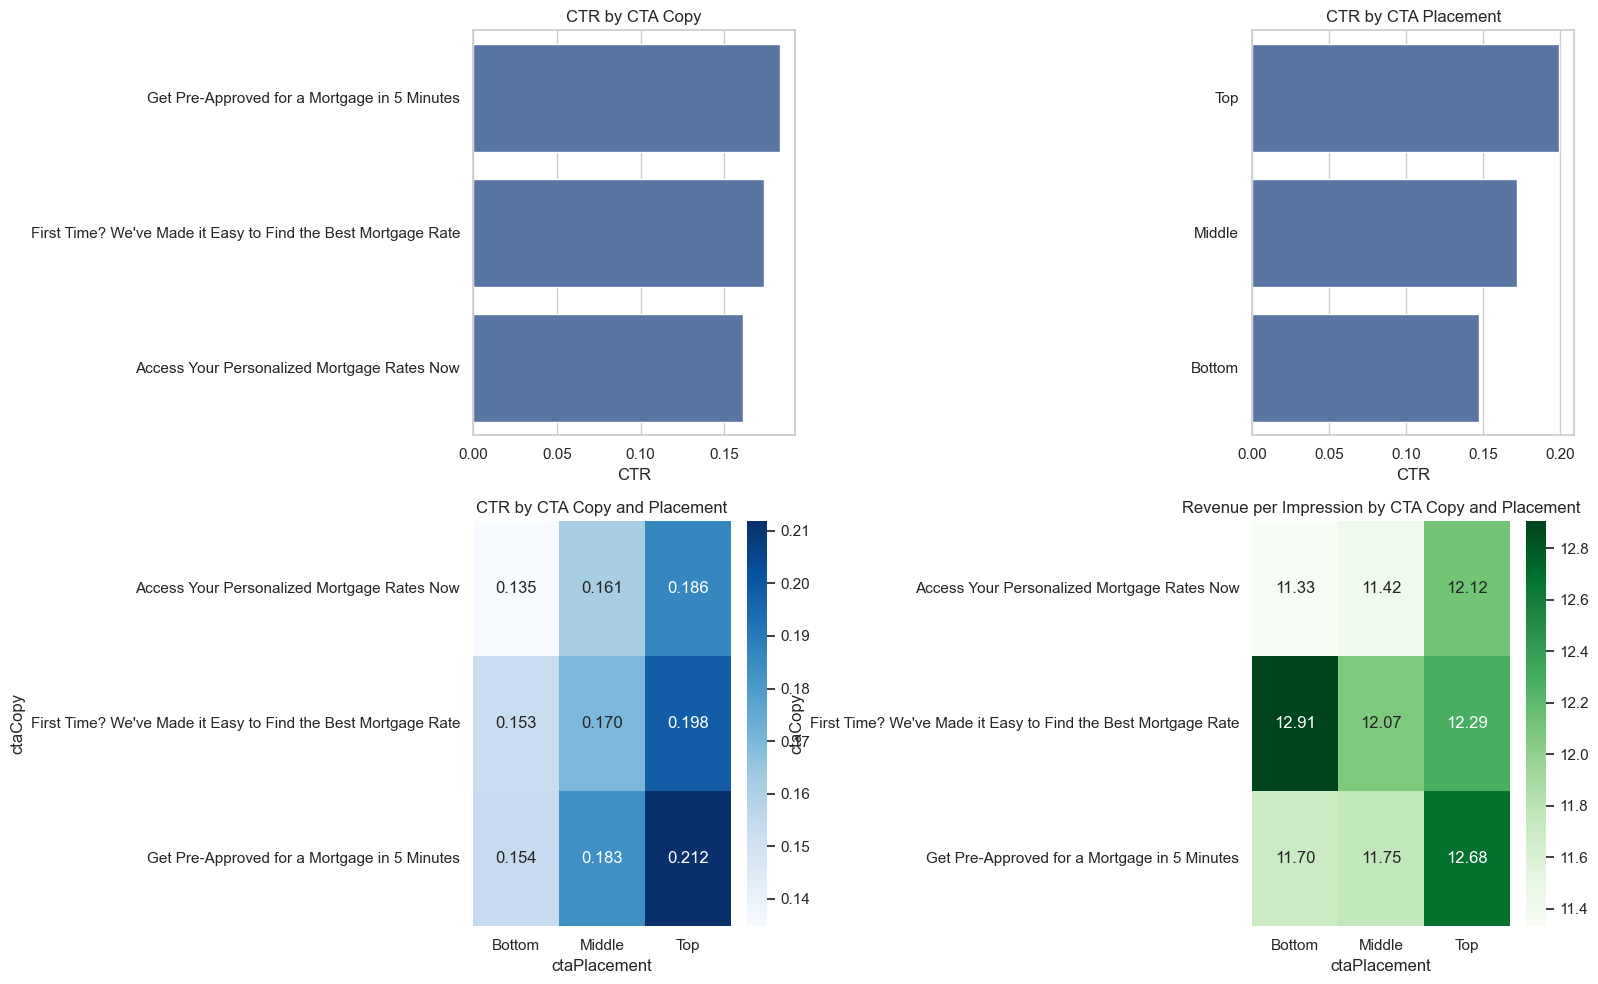

In [11]:
# Visual summaries make it easier to compare CTR and revenue winners side by side.
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.barplot(data=cta_copy_metrics, x="ctr", y="ctaCopy", ax=axes[0, 0])
axes[0, 0].set_title("CTR by CTA Copy")
axes[0, 0].set_xlabel("CTR")
axes[0, 0].set_ylabel("")

sns.barplot(data=cta_placement_metrics, x="ctr", y="ctaPlacement", ax=axes[0, 1])
axes[0, 1].set_title("CTR by CTA Placement")
axes[0, 1].set_xlabel("CTR")
axes[0, 1].set_ylabel("")

heatmap_ctr = cta_combo_metrics.pivot(index="ctaCopy", columns="ctaPlacement", values="ctr")
sns.heatmap(heatmap_ctr, annot=True, fmt=".3f", cmap="Blues", ax=axes[1, 0])
axes[1, 0].set_title("CTR by CTA Copy and Placement")

heatmap_revenue = cta_combo_metrics.pivot(index="ctaCopy", columns="ctaPlacement", values="revenue_per_impression")
sns.heatmap(heatmap_revenue, annot=True, fmt=".2f", cmap="Greens", ax=axes[1, 1])
axes[1, 1].set_title("Revenue per Impression by CTA Copy and Placement")

plt.tight_layout()
plt.show()



### Key Takeaways from the Exploratory Analysis
At the aggregate level, **CTA placement appears to be the strongest driver of click behavior**. The **Top** placement produced the highest CTR (**19.89%**), followed by **Middle** (**17.16%**) and **Bottom** (**14.74%**). CTA copy also matters, with **"Get Pre-Approved for a Mortgage in 5 Minutes"** generating the highest overall CTR (**18.31%**) among the three copy variants.


When we evaluate the full CTA combination, the **highest-CTR variant** is **"Get Pre-Approved for a Mortgage in 5 Minutes" placed at the Top**, with a CTR of **21.18%**. However, the **highest revenue-per-impression variant** is **"First Time? We've Made it Easy to Find the Best Mortgage Rate" placed at the Bottom**, with revenue per impression of **$12.91**. This is an important business finding: **the CTA combination that generates the most clicks is not necessarily the one that generates the most downstream value**. If the business optimizes only for CTR, it may miss combinations that produce fewer clicks but higher-value conversions.

The weakest-performing combination across both CTR and revenue per impression is **"Access Your Personalized Mortgage Rates Now" placed at the Bottom**. This suggests that both the wording of the CTA and a low-visibility page placement can materially reduce performance.



Segment performance for sessionReferrer:


,sessionReferrer,impressions,ctr,form_rate,appointment_rate,revenue_per_impression,ctr_rank,revenue_rank
0,Direct,17745,0.2391,0.2033,0.0781,17.1043,1.0000,1.0000
1,Email,16463,0.2127,0.1802,0.0713,15.5622,2.0000,2.0000
2,Google,57023,0.1546,0.1341,0.0484,10.5485,3.0000,3.0000
3,Social,8769,0.0801,0.0645,0.0227,4.7685,4.0000,4.0000



Segment performance for deviceType:


,deviceType,impressions,ctr,form_rate,appointment_rate,revenue_per_impression,ctr_rank,revenue_rank
0,Desktop,39966,0.2061,0.1711,0.0659,14.3836,1.0000,1.0000
1,Mobile,60034,0.1503,0.1324,0.0480,10.4637,2.0000,2.0000



Segment performance for browser:


...

,estimatedPropertyType,impressions,ctr,form_rate,appointment_rate,revenue_per_impression,ctr_rank,revenue_rank
0,Apartment,33402,0.1979,0.1665,0.0654,13.5460,1.0000,1.0000
2,Mobile Home,2668,0.1780,0.1518,0.0543,9.9194,2.0000,4.0000
3,Townhome,10964,0.1705,0.1455,0.0537,11.5054,3.0000,2.0000
1,House,52966,0.1568,0.1365,0.0491,11.2895,4.0000,3.0000



Segment performance for income_band:


,income_band,impressions,ctr,form_rate,appointment_rate,revenue_per_impression,ctr_rank,revenue_rank
0,"(49999.999, 85000.0]",16567,0.1832,0.1558,0.0592,11.1918,1.0000,4.0000
2,"(105000.0, 128000.0]",16200,0.1737,0.1462,0.0556,11.7935,2.0000,2.0000
1,"(85000.0, 105000.0]",15679,0.1732,0.1473,0.0585,11.5575,3.0000,3.0000
3,"(128000.0, 150000.0]",15796,0.1688,0.1429,0.0482,10.6277,4.0000,5.0000
4,"(150000.0, 400000.0]",15744,0.1632,0.1447,0.0529,14.6980,5.0000,1.0000



Segment performance for visit_band:


,visit_band,impressions,ctr,form_rate,appointment_rate,revenue_per_impression,ctr_rank,revenue_rank
1,2,13031,0.2136,0.1866,0.0718,15.6841,1.0000,1.0000
2,3-5,17019,0.2059,0.1714,0.0682,14.9409,2.0000,2.0000
3,6-10,9338,0.1611,0.1296,0.0549,11.6925,3.0000,3.0000
0,1,60612,0.1562,0.1358,0.0480,10.4796,4.0000,4.0000


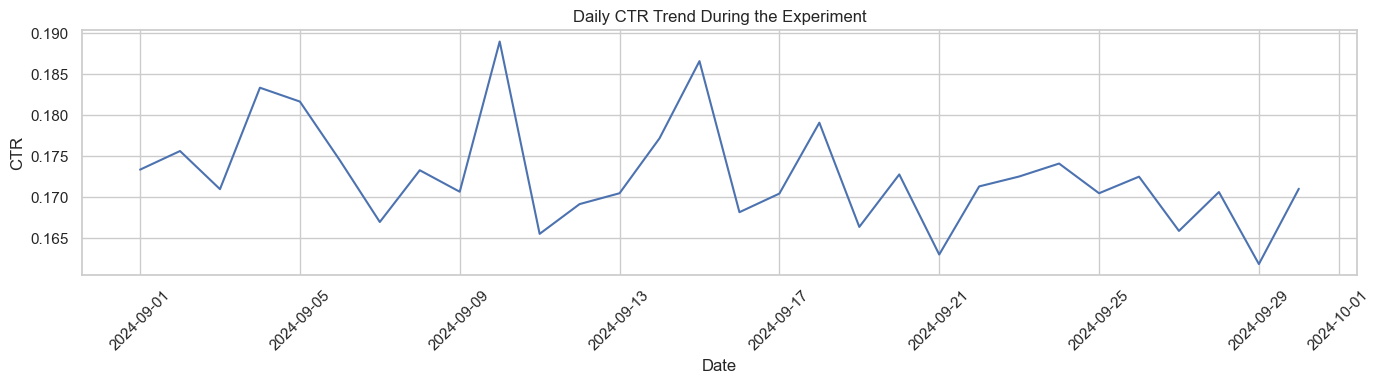

In [12]:
# Segment-level summaries help answer which audiences correlate more or less with the key metrics.
segment_columns = [
    "sessionReferrer",
    "deviceType",
    "browser",
    "estimatedPropertyType",
    "income_band",
    "visit_band",
]

segment_summaries = {}
for col in segment_columns:
    segment_summary = summarize_performance(eda, [col])
    segment_summary = segment_summary[segment_summary["impressions"] >= 1000]
    segment_summaries[col] = segment_summary
    print(f"\nSegment performance for {col}:")
    display(segment_summary)

# A daily trend check helps us see whether the experiment looks stable over time.
daily_trend = summarize_performance(eda, ["date"])
plt.figure(figsize=(14, 4))
sns.lineplot(data=daily_trend, x="date", y="ctr")
plt.title("Daily CTR Trend During the Experiment")
plt.xlabel("Date")
plt.ylabel("CTR")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Key Takeaways from the Exploratory Analysis
The segment analysis also shows meaningful user heterogeneity. Users from **Direct** and **Email** traffic sources have much stronger CTR, appointment rate, and revenue per impression than users from **Google** and especially **Social** traffic. **Desktop** users outperform **Mobile** users across all key metrics. By browser, **Firefox** and **Edge** users perform better than **Chrome** and **Safari** users. By property type, **Apartment** users show the strongest overall engagement and monetization, while **House** users perform worse on average. Repeat visitors also appear more valuable than first-visit users, with users in the **2-visit** and **3-5 visit** ranges producing stronger click and revenue outcomes.

Income provides another useful business nuance. The highest income band does **not** produce the highest CTR, but it does produce the highest revenue per impression. This suggests that some groups may click less often while still generating greater downstream business value once they convert.

Finally, the daily CTR trend appears relatively stable over the experiment period, with normal day-to-day fluctuation but no obvious structural shift. That stability supports treating this as a consistent experimental window rather than one dominated by a major time-based shock.

Overall, the exploratory analysis suggests three important conclusions. First, **placement matters a lot**, with top-of-page exposure clearly outperforming lower placements. Second, **CTR alone is not enough** to judge business success, because the click winner and revenue winner are different. Third, the variation across traffic source, device, visit history, and other user attributes suggests that **a personalized CTA strategy may outperform a single universal champion**.


## 6. Feature Engineering Strategy

The goal of feature engineering is to create predictors that improve click prediction while remaining faithful to the real decision setting. In other words, every feature used in the primary model should be available at the time the CTA is shown.

Based on the data dictionary, business context, and exploratory analysis, the feature engineering strategy focuses on five groups of signals.

First, I include **time-based features** derived from `date`, such as **day of week** and a **weekend indicator**, because user behavior may vary across the week even if the overall experiment appears relatively stable.

Second, I preserve the key **session and page context variables** such as `sessionReferrer`, `browser`, `deviceType`, `estimatedPropertyType`, `pageURL`, `ctaCopy`, and `ctaPlacement`. These variables describe who the user is, how they arrived, and what CTA variant they were shown, all of which are relevant to click behavior.

Third, we engineer more usable representations of **numeric behavioral context**. For `estimatedAnnualIncome`, we create both a **missing indicator** and **income bands**, since missingness itself may carry signal and income may have a non-linear relationship with click propensity. For `visitCount`, we create a **visit frequency band** to capture the difference between first-time and repeat visitors.

Fourth, we include a small number of **interaction features** to reflect plausible business effects. For example, the effectiveness of a CTA may depend on both its copy and placement, or a placement may work differently on desktop versus mobile. Candidate interaction terms include:
- `ctaCopy x ctaPlacement`
- `deviceType x ctaPlacement`
- `sessionReferrer x ctaCopy`

Finally, we create lightweight **editorial context features** from `editorialSnippet` without introducing a heavy NLP pipeline. Since the notebook should remain interpretable and not overcomplicated, simple features such as snippet length and word count are a reasonable first step.

Importantly, the primary model will exclude variables that introduce leakage or are not available at decision time, including `submittedForm`, `scheduledAppointment`, `mortgageVariation`, `revenue`, and likely `scrollDepth`.


In [13]:
# Section 6 focuses on creating modeling features that are available at CTA decision time.
feature_train = train.copy()
feature_test = test.copy()

# Store the columns that should never be used as predictors in the primary click model.
leakage_and_non_feature_cols = [
    "clickedCTA",
    "submittedForm",
    "scheduledAppointment",
    "mortgageVariation",
    "revenue",
    "scrollDepth",
    "userId",
    "date",
]

# Use training data to define reusable income bin edges, then apply the same bins to both train and test.
income_non_null = feature_train["estimatedAnnualIncome"].dropna()
income_bin_edges = np.unique(
    np.quantile(income_non_null, q=np.linspace(0, 1, 6))
)

def engineer_features(df):
    df = df.copy()

    # Train and test use different date formats, so parse them robustly.
    df["date"] = pd.to_datetime(df["date"], format="mixed")

    # Calendar features may capture weekly browsing differences.
    df["day_of_week"] = df["date"].dt.day_name()
    df["is_weekend"] = df["date"].dt.dayofweek.isin([5, 6]).astype(int)

    # Missingness in estimated income may itself be informative.
    df["income_missing"] = df["estimatedAnnualIncome"].isna().astype(int)

    # Income bands allow the model to capture non-linear relationships more easily.
    df["income_band"] = pd.cut(
        df["estimatedAnnualIncome"],
        bins=income_bin_edges,
        include_lowest=True,
        duplicates="drop",
    ).astype(str)

    # Group visit count into more interpretable repeat-visit buckets.
    df["visit_band"] = pd.cut(
        df["visitCount"],
        bins=[-1, 0, 1, 2, 5, 10, np.inf],
        labels=["0", "1", "2", "3-5", "6-10", "11+"],
    ).astype(str)

    # Lightweight text-context features from the editorial snippet.
    df["snippet_char_count"] = df["editorialSnippet"].fillna("").str.len()
    df["snippet_word_count"] = df["editorialSnippet"].fillna("").str.split().str.len()

    # Interaction features reflect plausible business differences in CTA effectiveness.
    df["cta_copy_placement"] = df["ctaCopy"].astype(str) + " | " + df["ctaPlacement"].astype(str)
    df["device_placement"] = df["deviceType"].astype(str) + " | " + df["ctaPlacement"].astype(str)
    df["referrer_copy"] = df["sessionReferrer"].astype(str) + " | " + df["ctaCopy"].astype(str)

    return df


feature_train = engineer_features(feature_train)
feature_test = engineer_features(feature_test)

# Define the feature columns that remain eligible for the primary click model.
feature_cols = [
    col for col in feature_train.columns
    if col not in leakage_and_non_feature_cols
]

print(f"Number of engineered feature columns before encoding: {len(feature_cols)}")
display(feature_train[feature_cols].head(3))


Number of engineered feature columns before encoding: 20


,sessionReferrer,browser,deviceType,estimatedAnnualIncome,estimatedPropertyType,visitCount,pageURL,ctaCopy,ctaPlacement,editorialSnippet,day_of_week,is_weekend,income_missing,income_band,visit_band,snippet_char_count,snippet_word_count,cta_copy_placement,device_placement,referrer_copy
0,Google,Safari,Mobile,"152,000.0000",Apartment,1,https://www.financialservices.com/mortgages/ty...,First Time? We've Made it Easy to Find the Bes...,Middle,"Understand the pros and cons of fixed-rate, ad...",Sunday,1,0,"(150000.0, 400000.0]",1,97,14,First Time? We've Made it Easy to Find the Bes...,Mobile | Middle,Google | First Time? We've Made it Easy to Fin...
1,Social,Safari,Mobile,"140,000.0000",Apartment,2,https://www.financialservices.com/mortgages/ho...,Access Your Personalized Mortgage Rates Now,Bottom,Equip yourself with knowledge. Understand the ...,Sunday,1,0,"(128000.0, 150000.0]",2,127,19,Access Your Personalized Mortgage Rates Now | ...,Mobile | Bottom,Social | Access Your Personalized Mortgage Rat...
2,Direct,Safari,Mobile,"128,000.0000",House,1,https://www.financialservices.com/mortgages/fi...,Access Your Personalized Mortgage Rates Now,Bottom,Navigate the home buying journey with confiden...,Sunday,1,0,"(105000.0, 128000.0]",1,127,18,Access Your Personalized Mortgage Rates Now | ...,Mobile | Bottom,Direct | Access Your Personalized Mortgage Rat...


In [14]:
# Separate numeric and categorical feature groups for the later modeling pipeline.
numeric_features = [
    "estimatedAnnualIncome",
    "visitCount",
    "is_weekend",
    "income_missing",
    "snippet_char_count",
    "snippet_word_count",
]

categorical_features = [
    "day_of_week",
    "sessionReferrer",
    "browser",
    "deviceType",
    "estimatedPropertyType",
    "pageURL",
    "ctaCopy",
    "ctaPlacement",
    "editorialSnippet",
    "income_band",
    "visit_band",
    "cta_copy_placement",
    "device_placement",
    "referrer_copy",
]

feature_summary = pd.DataFrame(
    {
        "feature_group": (
            ["numeric"] * len(numeric_features) +
            ["categorical"] * len(categorical_features)
        ),
        "feature_name": numeric_features + categorical_features,
    }
)

display(feature_summary)


,feature_group,feature_name
0,numeric,estimatedAnnualIncome
1,numeric,visitCount
2,numeric,is_weekend
3,numeric,income_missing
4,numeric,snippet_char_count
5,numeric,snippet_word_count
6,categorical,day_of_week
7,categorical,sessionReferrer
8,categorical,browser
9,categorical,deviceType


### Feature Engineering Summary

The engineered feature set combines user context, page context, calendar effects, lightweight text signals, and treatment interactions. Importantly, all retained features are available at the time the CTA decision is made, which keeps the primary click model aligned with the real business use case.

The final feature set includes:
- numeric context variables such as `estimatedAnnualIncome`, `visitCount`, `is_weekend`, `income_missing`, and simple editorial text length measures
- categorical context variables such as traffic source, browser, device type, property type, page URL, and day of week
- experimental treatment variables `ctaCopy` and `ctaPlacement`
- interaction features such as `cta_copy_placement`, `device_placement`, and `referrer_copy`

This design allows the model to capture both broad behavioral patterns and more targeted differences in how specific user or session contexts respond to different CTA strategies.


## 7. Modeling Approach

To model `Pr(clickedCTA = 1)`, I begin with a simple baseline and then move to more expressive models. This allows the analysis to show not only which model performs best, but also how much value is gained from added modeling complexity.

The modeling strategy includes three candidate approaches.

First, I use a **baseline classifier** that predicts the historical average click probability for every observation. This provides a minimum benchmark that any useful model should outperform.

Second, I use **regularized logistic regression** as the primary interpretable model. Logistic regression is a strong starting point for this problem because the target is binary, the required output is a probability, and the engineered feature set contains a mixture of one-hot encoded categorical variables and numeric signals. With regularization, logistic regression can also handle overlapping or redundant features more safely.

Third, I include a **random forest classifier** as a non-linear benchmark. While it is less interpretable than logistic regression, it can capture non-linear interactions and threshold effects that a linear model may miss.

For preprocessing, numeric variables will be imputed and scaled, while categorical variables will be imputed and one-hot encoded. All preprocessing steps are embedded in model pipelines so that training and prediction use the same transformations consistently.


In [15]:
# Section 7 defines the candidate models and the preprocessing steps used by each model.
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Separate the modeling inputs from the target.
X = feature_train[feature_cols].copy()
y = feature_train[TARGET_COL].copy()

# Numeric features are imputed and scaled.
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# Categorical features are imputed and one-hot encoded.
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

# Combine numeric and categorical preprocessing into one reusable transformer.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [16]:
# 1. Baseline model: predicts the historical positive-class rate for every row.
dummy_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DummyClassifier(strategy="prior")),
    ]
)

In [17]:
# 2. Interpretable linear benchmark with regularization.
log_reg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                solver="saga",
                penalty="l2",
                C=1.0,
                max_iter=2000,
                random_state=42,
            ),
        ),
    ]
)

For logistic regression, I use L2 regularization as the default choice because the feature set contains many one-hot encoded categorical variables and several overlapping interaction terms. L2 regularization shrinks coefficients without aggressively eliminating correlated predictors, which tends to produce a more stable model and better probability estimates for log-loss optimization.


In [18]:
# 3. Non-linear benchmark that can capture threshold effects and interactions.
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=12,
                min_samples_leaf=25,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)


In [19]:
# Store the candidate models in one dictionary so later evaluation code stays compact.
candidate_models = {
    "baseline_dummy": dummy_model,
    "logistic_regression": log_reg_model,
    "random_forest": rf_model,
}

print("Candidate models prepared:")
for model_name in candidate_models:
    print(f"- {model_name}")

    # Summarize the modeling setup before validation.
model_summary = pd.DataFrame(
    {
        "model_name": ["baseline_dummy", "logistic_regression", "random_forest"],
        "model_role": [
            "Baseline probability benchmark",
            "Primary interpretable model",
            "Non-linear benchmark",
        ],
        "key_strength": [
            "Sets the minimum performance bar",
            "Well-suited for calibrated probability prediction",
            "Captures non-linear effects and interaction structure",
        ],
    }
)

display(model_summary)


Candidate models prepared:
- baseline_dummy
- logistic_regression
- random_forest


,model_name,model_role,key_strength
0,baseline_dummy,Baseline probability benchmark,Sets the minimum performance bar
1,logistic_regression,Primary interpretable model,Well-suited for calibrated probability prediction
2,random_forest,Non-linear benchmark,Captures non-linear effects and interaction st...


## 8. Validation Strategy

Because the required output is a **probability** rather than just a class label, model evaluation should focus not only on ranking performance but also on probability quality. In this case, a good model should assign higher probabilities to users who are more likely to click, while also keeping those probabilities well calibrated.

The primary evaluation metric is **log loss**, which is also the official scoring metric in the case instructions. Log loss is especially appropriate here because it rewards accurate probability estimates and penalizes overconfident incorrect predictions. A lower log loss indicates better probabilistic performance.

To make model comparison more robust, I use **stratified 5-fold cross-validation**. Stratification preserves the class balance of `clickedCTA` across folds, which is important because the positive class rate is materially lower than the negative class rate. Cross-validation also reduces the chance that model conclusions are driven by one unusually favorable or unfavorable train-validation split.

In addition to log loss, I evaluate several complementary metrics:
- **ROC-AUC**, to measure how well the model ranks positive cases above negative cases
- **PR-AUC** (implemented as average precision), to better reflect performance on the positive class
- **Brier score**, to assess the accuracy and calibration of predicted probabilities

Finally, I reserve lift-style or decile-style analysis for later interpretation, since those views are most helpful once a final candidate model has been selected.


In [20]:
# Section 8 evaluates the candidate models using stratified cross-validation.
from sklearn.model_selection import StratifiedKFold, cross_validate

# Stratification keeps the click rate similar across folds.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# We optimize primarily for log loss, but also track ranking and calibration metrics.
scoring = {
    "log_loss": "neg_log_loss",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "brier_score": "neg_brier_score",
}

cv_results = []

for model_name, model in candidate_models.items():
    # Cross-validation gives a more stable performance estimate than a single holdout split.
    scores = cross_validate(
        estimator=model,
        X=X,
        y=y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    cv_results.append(
        {
            "model": model_name,
            "mean_log_loss": -scores["test_log_loss"].mean(),
            "std_log_loss": scores["test_log_loss"].std(),
            "mean_roc_auc": scores["test_roc_auc"].mean(),
            "mean_pr_auc": scores["test_pr_auc"].mean(),
            "mean_brier_score": -scores["test_brier_score"].mean(),
        }
    )

cv_results = pd.DataFrame(cv_results).sort_values("mean_log_loss").reset_index(drop=True)

# Lower log loss is better, while higher ROC-AUC and PR-AUC are better.
display(cv_results)


,model,mean_log_loss,std_log_loss,mean_roc_auc,mean_pr_auc,mean_brier_score
0,random_forest,0.4383,0.0008,0.6567,0.2849,0.1365
1,logistic_regression,0.4407,0.0012,0.6448,0.2718,0.1372
2,baseline_dummy,0.4600,0.0000,0.5000,0.1726,0.1428


### Validation Results Interpretation

The `random forest` is the strongest candidate model based on cross-validated performance. It achieved the lowest mean log loss, as well as the best ROC-AUC, PR-AUC, and Brier score among the three models tested. This suggests that the random forest is capturing useful non-linear effects and interaction structure beyond what the regularized logistic regression can model.

The `logistic regression` still performs substantially better than the baseline dummy model, which confirms that the engineered feature set contains meaningful predictive signal. However, its performance is consistently below the random forest across all evaluation metrics.

The `baseline dummy classifier` performs as expected: it provides a useful reference point but has no ranking power and the weakest probability performance. The very small standard deviation of log loss across folds suggests that the cross-validation results are stable and that the random forest advantage is not driven by a single favorable split.


## 9. Model Results

This section compares the candidate models and explains the final model choice. The goal is not only to identify the best-performing model on the validation metrics, but also to understand what the model is learning and what tradeoffs come with that choice.

The validation results show that the **random forest** is the strongest candidate based on cross-validated log loss, while also outperforming the other models on ROC-AUC, PR-AUC, and Brier score. This suggests that the random forest is capturing useful non-linear relationships and interaction effects that the logistic regression does not fully capture.

At the same time, the logistic regression remains an important benchmark. Although it does not achieve the best predictive performance, it is simpler and easier to interpret. This makes it useful as a reference point for understanding whether the extra complexity of the random forest is justified.

To interpret the selected model, I examine feature importance and out-of-fold prediction behavior. The out-of-fold predictions are especially useful because they provide a more realistic view of model performance than predictions generated on the same data used for fitting.


In [21]:
# Section 9 starts by restating the model comparison and selecting the final model.
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
)
from sklearn.model_selection import cross_val_predict

# Display the cross-validated model comparison table.
display(cv_results)

# Select the best model based on the lowest cross-validated log loss.
best_model_name = cv_results.loc[0, "model"]
best_model = candidate_models[best_model_name]

print(f"Final selected model: {best_model_name}")
print("Reason: it achieved the lowest cross-validated log loss and also led on the supporting metrics.")


,model,mean_log_loss,std_log_loss,mean_roc_auc,mean_pr_auc,mean_brier_score
0,random_forest,0.4383,0.0008,0.6567,0.2849,0.1365
1,logistic_regression,0.4407,0.0012,0.6448,0.2718,0.1372
2,baseline_dummy,0.4600,0.0000,0.5000,0.1726,0.1428


Final selected model: random_forest
Reason: it achieved the lowest cross-validated log loss and also led on the supporting metrics.


,feature_name,importance_mean,importance_std
0,sessionReferrer,0.0110,0.0002
1,pageURL,0.0075,0.0003
2,deviceType,0.0058,0.0003
3,estimatedPropertyType,0.0045,0.0001
4,referrer_copy,0.0045,0.0001
5,device_placement,0.0037,0.0001
6,editorialSnippet,0.0035,0.0001
7,snippet_char_count,0.0033,0.0002
8,ctaPlacement,0.0027,0.0002
9,ctaCopy,0.0027,0.0001


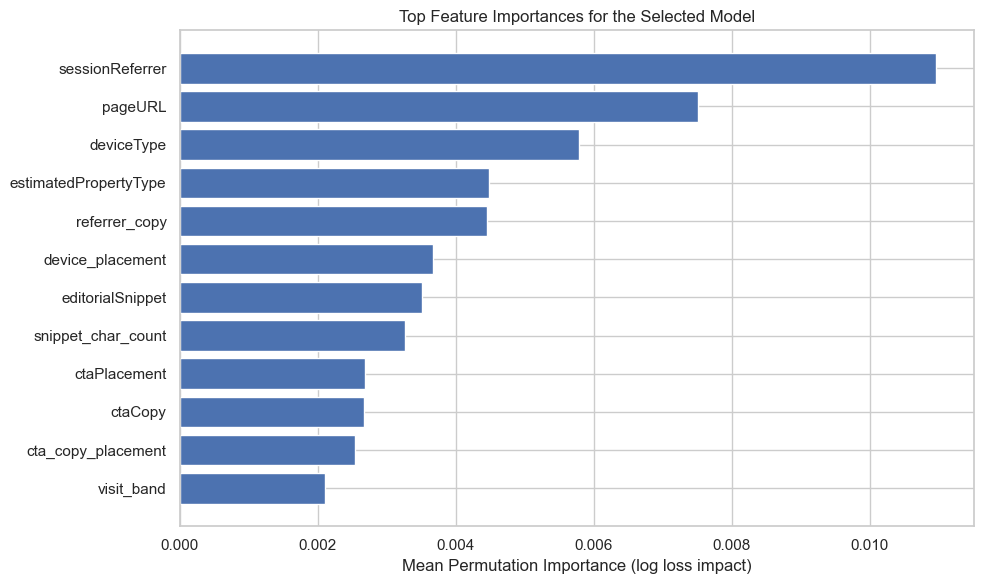

In [22]:
# Fit the final selected model on the full training data for interpretation.
best_model.fit(X, y)

# Use permutation importance on a sample of the training data to keep runtime manageable.
importance_sample_size = min(25000, len(X))
X_importance = X.sample(n=importance_sample_size, random_state=42)
y_importance = y.loc[X_importance.index]

perm_importance = permutation_importance(
    estimator=best_model,
    X=X_importance,
    y=y_importance,
    scoring="neg_log_loss",
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)

feature_importance_df = (
    pd.DataFrame(
        {
            "feature_name": X.columns,
            "importance_mean": perm_importance.importances_mean,
            "importance_std": perm_importance.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance_df.head(15))

# Plot the top features for a more readable visual summary.
top_n = 12
top_features = feature_importance_df.head(top_n).sort_values("importance_mean", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature_name"], top_features["importance_mean"])
plt.title("Top Feature Importances for the Selected Model")
plt.xlabel("Mean Permutation Importance (log loss impact)")
plt.ylabel("")
plt.tight_layout()
plt.show()


,metric,value
0,log_loss,0.4383
1,roc_auc,0.6566
2,pr_auc,0.2842
3,brier_score,0.1365


,prediction_decile,impressions,mean_predicted_probability,actual_ctr
0,"(0.0252, 0.0928]",10000,0.0748,0.0612
1,"(0.0928, 0.117]",10000,0.1060,0.0905
2,"(0.117, 0.134]",10000,0.1259,0.1132
3,"(0.134, 0.15]",10000,0.1418,0.1314
4,"(0.15, 0.167]",10000,0.1582,0.1527
5,"(0.167, 0.183]",10000,0.1751,0.1732
6,"(0.183, 0.201]",10000,0.1919,0.1934
7,"(0.201, 0.224]",10000,0.2116,0.2121
8,"(0.224, 0.26]",10000,0.2398,0.2540
9,"(0.26, 0.469]",10000,0.3003,0.3444


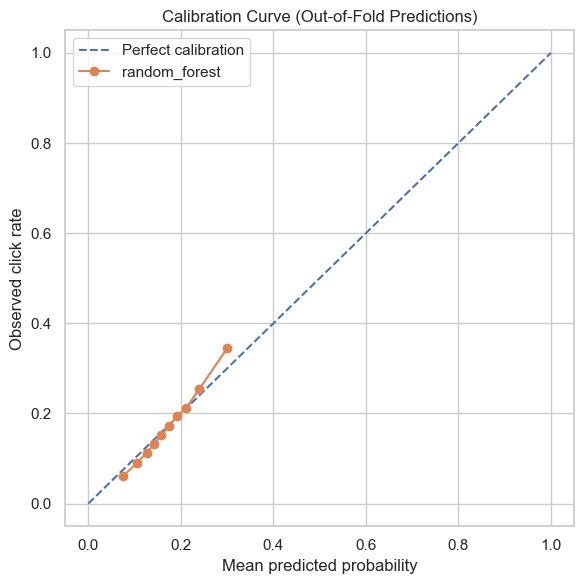

In [23]:
# Out-of-fold predictions give a realistic view of model behavior on unseen folds.
oof_pred_proba = cross_val_predict(
    estimator=best_model,
    X=X,
    y=y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

# Summarize the out-of-fold probability performance.
oof_metrics = pd.DataFrame(
    {
        "metric": ["log_loss", "roc_auc", "pr_auc", "brier_score"],
        "value": [
            log_loss(y, oof_pred_proba),
            roc_auc_score(y, oof_pred_proba),
            average_precision_score(y, oof_pred_proba),
            brier_score_loss(y, oof_pred_proba),
        ],
    }
)

display(oof_metrics)

# Group users into prediction deciles to see whether higher predicted probabilities correspond to higher actual CTR.
oof_eval = pd.DataFrame(
    {
        "actual_clicked": y,
        "predicted_probability": oof_pred_proba,
    }
)

oof_eval["prediction_decile"] = pd.qcut(
    oof_eval["predicted_probability"],
    q=10,
    duplicates="drop",
)

decile_summary = (
    oof_eval.groupby("prediction_decile", observed=True)
    .agg(
        impressions=("actual_clicked", "size"),
        mean_predicted_probability=("predicted_probability", "mean"),
        actual_ctr=("actual_clicked", "mean"),
    )
    .reset_index()
)

display(decile_summary)

# Calibration curve compares predicted probabilities against realized click rates.
calibration_true, calibration_pred = calibration_curve(
    y_true=y,
    y_prob=oof_pred_proba,
    n_bins=10,
    strategy="quantile",
)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.plot(calibration_pred, calibration_true, marker="o", label=best_model_name)
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed click rate")
plt.title("Calibration Curve (Out-of-Fold Predictions)")
plt.legend()
plt.tight_layout()
plt.show()


### Model Results Interpretation

The **random forest** is selected as the final model because it achieved the best cross-validated performance across all tracked metrics. It produced the **lowest log loss (0.4383)**, the **highest ROC-AUC (0.6566)**, the **highest PR-AUC (0.2842)**, and the **lowest Brier score (0.1365)** among the candidate models. This indicates that it performs best not only in ranking likely clickers above non-clickers, but also in producing useful probability estimates.

The feature importance analysis suggests that the model relies most heavily on **traffic source (`sessionReferrer`)**, followed by **page context (`pageURL`)**, **device type**, and **estimated property type**. This is consistent with the earlier exploratory analysis, which showed strong performance differences across traffic source, device, and content context. Interaction-style features such as **`referrer_copy`** and **`device_placement`** also rank highly, which supports the idea that CTA performance depends not only on the CTA itself, but also on the type of user and session context in which it appears.

The treatment variables remain important as well. Both **`ctaPlacement`**, **`ctaCopy`**, and the combined interaction **`cta_copy_placement`** appear in the top feature list, confirming that the experimental design variables contain predictive value. However, the feature importance ranking also shows that user and session context contribute at least as much signal as the CTA treatment alone. This strengthens the business case for **personalization**, rather than serving a single CTA combination uniformly to all users.

The out-of-fold prediction analysis shows that the model separates users into meaningful risk bands. The observed click-through rate rises steadily across prediction deciles, from **6.12%** in the lowest decile to **34.44%** in the highest decile. This is a strong practical result: the model is not only improving standard validation metrics, but also concentrating much higher click propensity in the top-scored users.

The calibration curve suggests that the model is **reasonably well calibrated overall**, with predicted probabilities tracking observed click rates fairly closely across most of the range. There is some evidence that the model is slightly **conservative in the highest-probability segment**, where the observed click rate exceeds the mean predicted probability. In other words, the model slightly **underpredicts** the strongest clickers. At the lower end, the model appears slightly **overpredictive**, but the deviation is modest. Overall, the calibration quality is good enough to support probability-based decision making.

There is still an important tradeoff between **predictive performance** and **interpretability**. The random forest outperforms logistic regression on every validation metric, so it is the strongest final model for prediction. However, logistic regression remains easier to explain directly through coefficients. In this case, the performance improvement from the random forest appears large enough to justify the added complexity, while the earlier exploratory analysis and permutation importance results still provide a useful interpretive layer.


## 10. Test Set Prediction and Submission

After selecting the random forest as the final model, I train it on the full training dataset and generate predicted click probabilities for the unlabeled test set. These predictions are then formatted into the required submission structure with two columns: `userId` and `pr_CTA`.

Because the competition requires probability predictions rather than class labels, the submission uses the model's predicted probability for `clickedCTA = 1` for each user in the test set.



In [24]:
from make_submission import make_submission

# Section 10 fits the selected model on the full training data and scores the test set.
final_model = candidate_models[best_model_name]

# Train the final model on all available labeled data.
final_model.fit(X, y)

# Score the test set.
X_test = feature_test[feature_cols].copy()

# Predict click probabilities for the unlabeled test set.
test_pred_proba = final_model.predict_proba(X_test)[:, 1]

# Create the submission DataFrame in the required format.
submission = pd.DataFrame(
    {
        "userId": test[ID_COL],
        "pr_CTA": test_pred_proba,
    }
)

# Basic sanity checks before exporting.
assert list(submission.columns) == ["userId", "pr_CTA"]
assert submission["userId"].nunique() == len(submission)
assert submission["pr_CTA"].between(0, 1).all()

display(submission.head())

make_submission("Yang_predictions", submission)



,userId,pr_CTA
0,user_175722,0.1327
1,user_180185,0.2604
2,user_119865,0.2560
3,user_176700,0.1023
4,user_192992,0.3458


'Yang_predictions.csv written in 0.000 ms'